# Face Recognition Attendance System

## Project Overview

This project is a Machine Learning-based Face Recognition Attendance System developed using Python and Google Colab. The system recognizes known faces from an uploaded image, marks the recognized person's attendance automatically, and generates an attendance sheet in CSV format.

### Objectives

- Detect human faces from an image
- Recognize registered individuals
- Generate an attendance sheet automatically
- Save attendance records with date and time

### Tools & Technologies

- Python
- Google Colab
- OpenCV
- Face Recognition Library
- NumPy
- Pandas
- Matplotlib

In [1]:
# ==========================================
# Face Recognition Attendance System
# Developed by: Ismam Ahmed
# Platform: Google Colab
# ==========================================

print("Face Recognition Attendance System")
print("Project Started Successfully!")

Face Recognition Attendance System
Project Started Successfully!


# Face Recognition Attendance System

## Student Information

**Student1 Name:** Ismam Ahmed<br>
**Student2 Name:** Tamanna Khokon<br>
**Student3 Name:** Tasnim Jahan<br>

**Project:** Face Recognition Attendance System

**Language:** Python

**Platform:** Google Colab

# Step 1: Install Required Libraries

In [3]:
# Install required libraries

!apt-get -qq update
!apt-get -qq install -y cmake libopenblas-dev liblapack-dev

!pip install face_recognition
!pip install opencv-python
!pip install pandas
!pip install numpy
!pip install matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=0de51fbdf5d60fac5f3747a49278a99f4340242f16cfc748c56cec08660c01ea
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [5]:
import face_recognition
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Step 2: Upload Known Faces

In [6]:
from google.colab import files

print("Upload Known_Faces.zip")

uploaded = files.upload()

Upload Known_Faces.zip


Saving Known_Faces.zip to Known_Faces.zip


In [8]:
import zipfile
import os

zip_path = "Known_Faces.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

print(" Known_Faces extracted successfully!")

 Known_Faces extracted successfully!


In [9]:
import os

known_folder = "Known_Faces"

print("People in database:\n")

for file in os.listdir(known_folder):
    print(file)

People in database:

Purnota.jfif
Tamanna.jpg
Neymar.jfif
Ismam.jpg
Messi.jfif


# Step 3: Encode Known Faces

In [12]:
import face_recognition
import os

# Folder containing known faces
KNOWN_FACES_DIR = "Known_Faces"

known_face_encodings = []
known_face_names = []

print("Encoding known faces...\n")

for filename in os.listdir(KNOWN_FACES_DIR):

    image_path = os.path.join(KNOWN_FACES_DIR, filename)

    # Load image
    image = face_recognition.load_image_file(image_path)

    # Encode face
    encodings = face_recognition.face_encodings(image)

    # Skip images with no face
    if len(encodings) == 0:
        print(f" No face found in {filename}")
        continue

    known_face_encodings.append(encodings[0])

    # Remove file extension (.jpg/.jfif/.png)
    name = os.path.splitext(filename)[0]

    known_face_names.append(name)

    print(f"✅ {name} encoded successfully!")

print("\n--------------------------------")
print("Database Ready!")
print(f"Total Faces Encoded: {len(known_face_names)}")

Encoding known faces...

✅ Purnota encoded successfully!
✅ Tamanna encoded successfully!
✅ Neymar encoded successfully!
✅ Ismam encoded successfully!
✅ Messi encoded successfully!

--------------------------------
Database Ready!
Total Faces Encoded: 5


In [31]:
# Student IDs

known_face_ids = {
    "Ismam": "043220005101116",
    "Messi": "0432310005101010",
    "Neymar": "0432310005101011",
    "Purnota": "0432310005101089",
    "Tamanna": "0432310005101082"
}

print("Student IDs Loaded Successfully!")

Student IDs Loaded Successfully!


# Step 4: Upload Test Image

In [13]:
from google.colab import files

print("Upload a test image")

uploaded = files.upload()

Upload a test image


Saving Purnota2.jpg to Purnota2.jpg


Faces Detected: 1
Recognized: Purnota


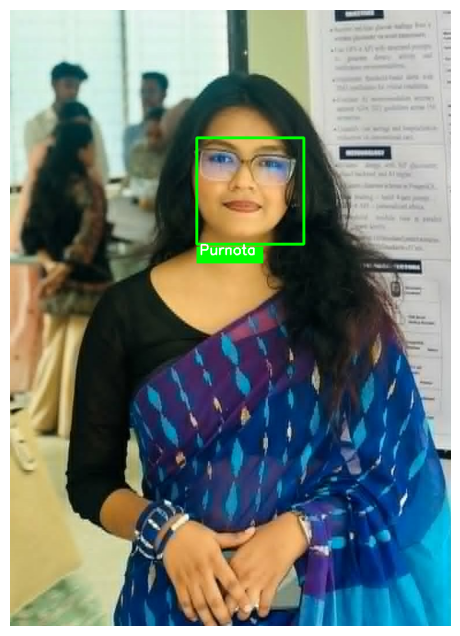

In [16]:
import face_recognition
import cv2
import matplotlib.pyplot as plt

# Get uploaded filename
test_image_name = list(uploaded.keys())[0]

# Load image
image = face_recognition.load_image_file(test_image_name)

# Detect faces
face_locations = face_recognition.face_locations(image)

# Encode detected faces
face_encodings = face_recognition.face_encodings(image, face_locations)

print(f"Faces Detected: {len(face_encodings)}")

# Convert RGB -> BGR for OpenCV
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

    matches = face_recognition.compare_faces(
        known_face_encodings,
        face_encoding
    )

    name = "Unknown"

    if True in matches:
        first_match_index = matches.index(True)
        name = known_face_names[first_match_index]

    print("Recognized:", name)

    # Draw thicker green rectangle around face
    cv2.rectangle(
        image,
        (left, top),
        (right, bottom),
        (0, 255, 0),
        3
    )

    # Calculate text size
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.8
    thickness = 2

    (text_width, text_height), baseline = cv2.getTextSize(
        name,
        font,
        font_scale,
        thickness
    )

    # Draw green background for text (auto width)
    cv2.rectangle(
        image,
        (left, bottom + 5),
        (left + text_width + 15, bottom + text_height + 15),
        (0, 255, 0),
        cv2.FILLED
    )

    # Write name
    cv2.putText(
        image,
        name,
        (left + 5, bottom + text_height),
        font,
        font_scale,
        (255, 255, 255),
        thickness
    )

# Convert back to RGB for matplotlib
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.show()

# Step 5: Generate Attendance Sheet

In [32]:
import pandas as pd
from datetime import datetime

attendance = []

for face_encoding in face_encodings:

    matches = face_recognition.compare_faces(
        known_face_encodings,
        face_encoding
    )

    name = "Unknown"

    if True in matches:
        first_match = matches.index(True)
        name = known_face_names[first_match]

    attendance.append({
        "Student ID": known_face_ids.get(name, "N/A"),
        "Name": name,
        "Date": datetime.now().strftime("%d-%m-%Y"),
        "Time": datetime.now().strftime("%H:%M:%S"),
        "Status": "Present"
    })

attendance_df = pd.DataFrame(attendance)

attendance_df

,Student ID,Name,Date,Time,Status
0,0432310005101089,Purnota,27-06-2026,10:45:58,Present


In [23]:
from datetime import datetime

# Create timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

attendance_filename = f"Attendance_{timestamp}.csv"

attendance_df.to_csv(attendance_filename, index=False)

print(f"✅ Attendance saved as {attendance_filename}")

✅ Attendance saved as Attendance_20260627_103131.csv


In [24]:
from google.colab import files

files.download(attendance_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
image_filename = f"Recognized_Output_{timestamp}.jpg"

cv2.imwrite(
    image_filename,
    cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
)

print(f"✅ Image saved as {image_filename}")

✅ Image saved as Recognized_Output_20260627_103131.jpg


In [22]:
files.download(image_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>